In [1]:
# Task 1: Heart Disease Classification
# Step 1: Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)
   
print("All libraries imported successfully!")

All libraries imported successfully!


In [2]:
# Step 2: Load the Heart Disease dataset

url = "https://raw.githubusercontent.com/reinaldoq/processing-heart-disease-dataset/master/processed.cleveland.data"

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs",
    "restecg", "thalach", "exang", "oldpeak",
    "slope", "ca", "thal", "target"
]

df = pd.read_csv(url, names=columns, na_values="?")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# Step 2: Load the Heart Disease dataset

url = "https://raw.githubusercontent.com/reinaldoq/processing-heart-disease-dataset/master/processed.cleveland.data"

columns = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal",
    "target"
]

df = pd.read_csv(url, names=columns, na_values="?")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [4]:
# Step 3: Inspect the dataset

print("Dataset information:")
print(df.info())

print("\nMissing values in each column:")
print(df.isnull().sum())

print("\nTarget value counts:")
print(df["target"].value_counts())

Dataset information:
<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB
None

Missing values in each column:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal

In [5]:
# Step 4: Data preprocessing

# Handle missing values using median
df["ca"] = df["ca"].fillna(df["ca"].median())
df["thal"] = df["thal"].fillna(df["thal"].median())

# Convert target into binary classification
# 0 = No heart disease
# 1-4 = Heart disease
df["target"] = (df["target"] > 0).astype(int)

print("Missing values after preprocessing:")
print(df.isnull().sum())

print("\nNew target distribution:")
print(df["target"].value_counts())

print("\nPreprocessing completed successfully!")

Missing values after preprocessing:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

New target distribution:
target
0    164
1    139
Name: count, dtype: int64

Preprocessing completed successfully!


In [6]:
# Step 5: Separate features and target, then split the data

# Features
X = df.drop("target", axis=1)

# Target
y = df["target"]

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Data split successfully!")
print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Data split successfully!
Training set: (242, 13)
Testing set: (61, 13)
Training target: (242,)
Testing target: (61,)


In [7]:
# Step 6: Feature scaling

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully!")
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Feature scaling completed successfully!
Scaled training data shape: (242, 13)
Scaled testing data shape: (61, 13)


In [8]:
# Step 7: Train Logistic Regression model

logistic_model = LogisticRegression(max_iter=1000, random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = logistic_model.predict(X_test_scaled)
y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression model trained successfully!")
print("Predictions generated successfully!")

Logistic Regression model trained successfully!
Predictions generated successfully!


In [9]:
# Step 8: Evaluate Logistic Regression

accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
roc_auc_lr = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print(f"Accuracy  : {accuracy_lr:.4f}")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1-Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Performance
--------------------------------
Accuracy  : 0.8689
Precision : 0.8125
Recall    : 0.9286
F1-Score  : 0.8667
ROC-AUC   : 0.9513

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



In [10]:
# Step 9: Train Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = random_forest_model.predict(X_test)
y_prob_rf = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest model trained successfully!")
print("Predictions generated successfully!")

Random Forest model trained successfully!
Predictions generated successfully!


In [11]:
# Step 10: Evaluate Random Forest

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy  : {accuracy_rf:.4f}")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1-Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Performance
-------------------------
Accuracy  : 0.9016
Precision : 0.8438
Recall    : 0.9643
F1-Score  : 0.9000
ROC-AUC   : 0.9545

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.85      0.90        33
           1       0.84      0.96      0.90        28

    accuracy                           0.90        61
   macro avg       0.90      0.91      0.90        61
weighted avg       0.91      0.90      0.90        61



In [12]:
# Step 11: Compare both models

comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Logistic Regression": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr,
        roc_auc_lr
    ],
    "Random Forest": [
        accuracy_rf,
        precision_rf,
        recall_rf,
        f1_rf,
        roc_auc_rf
    ]
})

display(comparison.round(4))

,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8689,0.9016
1,Precision,0.8125,0.8438
2,Recall,0.9286,0.9643
3,F1-Score,0.8667,0.9000
4,ROC-AUC,0.9513,0.9545


In [13]:
# Step 12: 5-Fold Cross-Validation

lr_cv_scores = cross_val_score(
    logistic_model,
    X_train_scaled,
    y_train,
    cv=5,
    scoring="accuracy"
)

rf_cv_scores = cross_val_score(
    random_forest_model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("5-Fold Cross-Validation Results")
print("--------------------------------")
print(f"Logistic Regression scores: {lr_cv_scores}")
print(f"Logistic Regression mean accuracy: {lr_cv_scores.mean():.4f}")
print()
print(f"Random Forest scores: {rf_cv_scores}")
print(f"Random Forest mean accuracy: {rf_cv_scores.mean():.4f}")

5-Fold Cross-Validation Results
--------------------------------
Logistic Regression scores: [0.91836735 0.7755102  0.83333333 0.83333333 0.77083333]
Logistic Regression mean accuracy: 0.8263

Random Forest scores: [0.87755102 0.7755102  0.85416667 0.75       0.79166667]
Random Forest mean accuracy: 0.8098


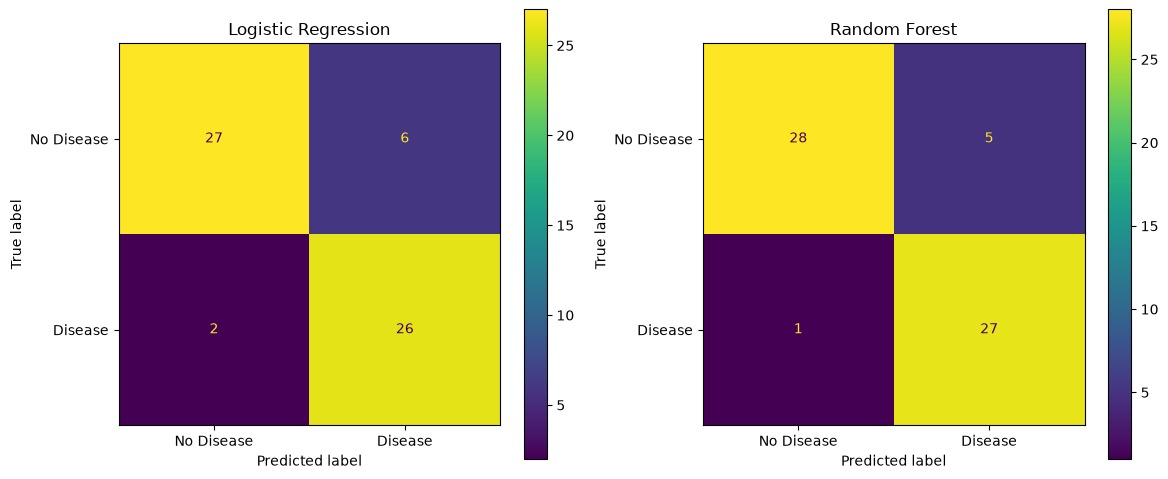

In [14]:
# Step 13: Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Logistic Regression
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["No Disease", "Disease"]
).plot(ax=axes[0])
axes[0].set_title("Logistic Regression")

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["No Disease", "Disease"]
).plot(ax=axes[1])
axes[1].set_title("Random Forest")

plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

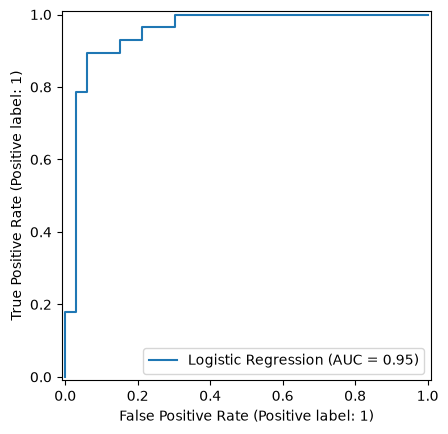

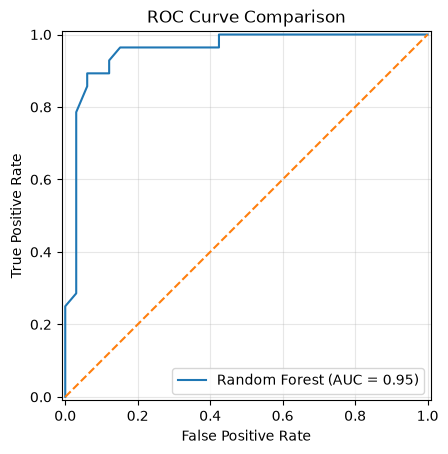

In [15]:
# Step 13: ROC Curve Comparison

plt.figure(figsize=(8, 6))

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_lr,
    name="Logistic Regression"
)

RocCurveDisplay.from_predictions(
    y_test,
    y_prob_rf,
    name="Random Forest"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [16]:
# Step 14: Final model comparison and conclusion

print("FINAL MODEL COMPARISON")
print("=" * 50)

display(comparison.round(4))

print("\nTest Set Performance")
print("=" * 50)

print(f"Logistic Regression Accuracy : {accuracy_lr:.4f}")
print(f"Random Forest Accuracy      : {accuracy_rf:.4f}")

print(f"\nLogistic Regression Precision: {precision_lr:.4f}")
print(f"Random Forest Precision     : {precision_rf:.4f}")

print(f"\nLogistic Regression Recall   : {recall_lr:.4f}")
print(f"Random Forest Recall        : {recall_rf:.4f}")

print(f"\nLogistic Regression F1-Score : {f1_lr:.4f}")
print(f"Random Forest F1-Score      : {f1_rf:.4f}")

print(f"\nLogistic Regression ROC-AUC  : {roc_auc_lr:.4f}")
print(f"Random Forest ROC-AUC       : {roc_auc_rf:.4f}")

print("\nCross-Validation Results")
print("=" * 50)

print(f"Logistic Regression Mean CV Accuracy: {lr_cv_scores.mean():.4f}")
print(f"Random Forest Mean CV Accuracy      : {rf_cv_scores.mean():.4f}")

print("\nConclusion")
print("=" * 50)

if accuracy_rf > accuracy_lr:
    print("Random Forest performed better than Logistic Regression "
          "on the test set based on Accuracy.")
else:
    print("Logistic Regression performed better than Random Forest "
          "on the test set based on Accuracy.")

FINAL MODEL COMPARISON


,Metric,Logistic Regression,Random Forest
0,Accuracy,0.8689,0.9016
1,Precision,0.8125,0.8438
2,Recall,0.9286,0.9643
3,F1-Score,0.8667,0.9000
4,ROC-AUC,0.9513,0.9545



Test Set Performance
Logistic Regression Accuracy : 0.8689
Random Forest Accuracy      : 0.9016

Logistic Regression Precision: 0.8125
Random Forest Precision     : 0.8438

Logistic Regression Recall   : 0.9286
Random Forest Recall        : 0.9643

Logistic Regression F1-Score : 0.8667
Random Forest F1-Score      : 0.9000

Logistic Regression ROC-AUC  : 0.9513
Random Forest ROC-AUC       : 0.9545

Cross-Validation Results
Logistic Regression Mean CV Accuracy: 0.8263
Random Forest Mean CV Accuracy      : 0.8098

Conclusion
Random Forest performed better than Logistic Regression on the test set based on Accuracy.
